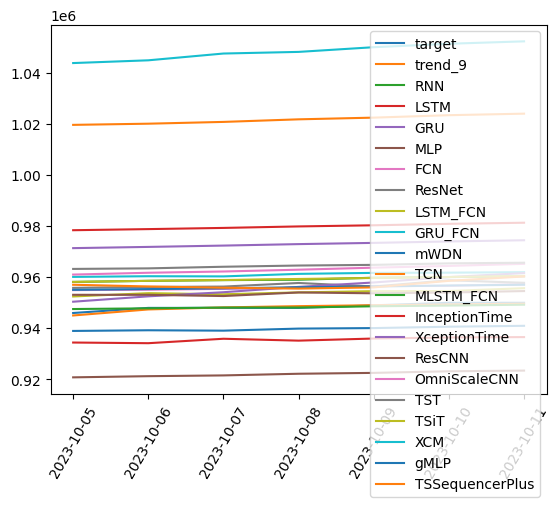

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import savemat

df_t = pd.read_csv('results_persona/target.csv')
date = df_t['date']
df_t = df_t['Owners']
df_9 = pd.read_csv('results_persona/trend_9.csv')['Owners']
#df_RNN = pd.read_csv('results_D/Detroit_RNNpreds_14.csv')['Owners']
#df_LSTM = pd.read_csv('results_D/Detroit_LSTMpreds_14.csv')['Owners']
#df_FCN = pd.read_csv('results_D/Detroit_FCNpreds_14.csv')['Owners']
#df_ResNet = pd.read_csv('results_D/Detroit_ResNetpreds_14.csv')['Owners']
#df_TST = pd.read_csv('results_D/Detroit_TSTpreds_14.csv')['Owners']
#plt.plot(date, df_t)
#plt.plot(date, df_9)
#plt.plot(date, df_RNN)
#plt.plot(date, df_LSTM)
#plt.plot(date, df_FCN)
#plt.plot(date, df_ResNet)
# plt.suptitle('tsai Prediction')
#plt.legend(['target', 'trend_9', 'LSTM', 'FCN'])
# plt.legend(['target', 'trend_7', 'RNN','LSTM', 'FCN']) # , loc='upper left'
#plt.xticks(range(0, len(date), 1), date[::1], rotation=75)
#plt.savefig('figs/Persona_'+models_name+'_Predictions.png', bbox_inches='tight')
#plt.show()

model_list = ["RNN", "LSTM", "GRU", "MLP", "FCN", 'ResNet', 'LSTM_FCN', 'GRU_FCN', 
                    'mWDN', 'TCN', 'MLSTM_FCN', 'InceptionTime',  'XceptionTime',  'ResCNN',  
                    'OmniScaleCNN', 'TST',  'TSiT',  'XCM', 'gMLP',  'TSSequencerPlus']

plt.plot(date, df_t)
plt.plot(date, df_9)

for models_name in model_list:
    df = pd.read_csv('results_persona/persona_'+models_name+'preds_7.csv')['Owners']
    savemat('MAT_P/'+models_name+".mat", {models_name: df})  # 方面后面用matlab画图，matlab处理 
    plt.plot(date, df)

plt.xticks(date, rotation=60)
plt.legend(['target', 'trend_9']+model_list)
plt.show()


In [3]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# # 实际值
# actual = np.array([1, 2, 3, 4, 5])
# # 预测值
# predicted = np.array([1.5, 2.5, 3.5, 4.5, 5.5])

def get_metric(actual, predicted):
    # 计算MAE
    mae = mean_absolute_error(actual, predicted)
    # 计算MAPE
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    # 计算MSE
    mse = mean_squared_error(actual, predicted)
    # 计算RMSE
    rmse = np.sqrt(mse)
    # 计算R^2
    r2 = r2_score(actual, predicted)
    return mae, mape, mse, rmse, r2

df_t = pd.read_csv('results_persona/target.csv')['Owners']
df_9 = pd.read_csv('results_persona/trend_9.csv')['Owners']

model_list = ["RNN", "LSTM", "GRU", "MLP", "FCN", 'ResNet', 'LSTM_FCN', 'GRU_FCN', 
                    'mWDN', 'TCN', 'MLSTM_FCN', 'InceptionTime',  'XceptionTime',  'ResCNN',  
                    'OmniScaleCNN', 'TST',  'TSiT',  'XCM', 'gMLP',  'TSSequencerPlus']


for models_name in model_list:
    df = pd.read_csv('results_persona/persona_'+models_name+'preds_7.csv')['Owners']
    mae, mape, mse, rmse, r2 = get_metric(df, df_t)
    print(mae, mape, mse, rmse, r2)


599.8571428571429 0.0632526823258151 622888.1428571428 789.2326291133323 -0.9757957004630458
31443.0 3.208914997604681 988922283.0 31447.13473434424 -992.1041432098993
24517.14285714286 2.519909366999649 601328547.7142857 24522.00129912495 -552.3306381066762
26283.428571428572 2.850219319331889 691110515.4285715 26288.98087466632 -824.8203539883434
7578.571428571428 0.7927624741772243 57890952.85714286 7608.61044193635 -86.06691673682688
8592.142857142857 0.897794792198124 74580371.0 8635.992762850141 -69.78245324337486
5646.285714285715 0.591833425240709 32177273.42857143 5672.501514197368 -34.184608159873534
12672.142857142857 1.318534896876775 161153977.2857143 12694.64364547955 -303.32352719464905
8585.285714285714 0.9134461218285721 74238429.0 8616.172526127828 -140.63440177339544
73355.28571428571 7.179104093539415 5381374082.142858 73357.84949235397 -2267.768825362107
10844.285714285714 1.130509006362931 117980382.0 10861.877462022852 -204.15692849095723
12900.714285714286 1.378